# Análisis de Padres/Cuidadores - Violencia Digital
Este notebook procesa los datos de la encuesta de padres de familia (cuidadores), integrando la limpieza de dimensiones demográficas y el cálculo de los índices de Conocimiento sobre Seguridad Digital y Capacidades de Acompañamiento Familiar para exportar la capa final hacia Power BI.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuración de visualización
sns.set_theme(style="whitegrid")

# Crear carpeta output si no existe
os.makedirs('../output', exist_ok=True)

# Cargar datos crudos
df_padres = pd.read_excel('../raw_data/BBDD_Padres_dash.xlsx')
print(f"Datos cargados: {df_padres.shape}")

Datos cargados: (330, 90)


## 1. Cálculo de Índices (Conocimiento y Acompañamiento Familiar)

In [2]:
def evaluar_conocimiento_padres(df):
    col_q2 = '2. ¿Ha escuchado alguna vez los siguientes términos? \n(Puede marcar más de una opción)'
    df['Puntaje_Q2'] = df[col_q2].apply(lambda x: 0 if 'No he escuchado' in str(x) or str(x) == 'nan' else 1)

    col_q3 = '3. ¿Cuáles de estas situaciones considera que son formas de violencia digital contra un niño/a o adolescente?\n(Puede marcar más de una opción)'
    df['Puntaje_Q3'] = df[col_q3].apply(lambda x: 0 if 'No estoy seguro/a' in str(x) or str(x) == 'nan' else 1)

    col_q4 = '4. ¿Sabe usted identificar señales de que un niño/a o adolescente puede estar siendo víctima de violencia digital?\n(Puede marcar más de una opción)'
    df['Puntaje_Q4'] = df[col_q4].apply(lambda x: 0 if 'No conozco señales' in str(x) or str(x) == 'nan' else 1)

    col_q5 = '5.  ¿Cómo describiría usted la violencia digital?\nMarque la opción que mejor refleje su comprensión:'
    df['Puntaje_Q5'] = df[col_q5].apply(lambda x: 1 if 'cualquier forma de daño' in str(x).lower() else 0)

    def mapear_q6(x):
        t = str(x).lower()
        if 'conozco bien' in t: return 3
        if 'sé bastante' in t: return 2
        if 'he escuchado algo' in t: return 1
        return 0
    
    cols_q6 = [c for c in df.columns if c.startswith('6. ')]
    for c in cols_q6:
        df[c + '_num'] = df[c].apply(mapear_q6)
    df['Puntaje_Q6'] = df[[c + '_num' for c in cols_q6]].sum(axis=1)

    cols_conocimiento = ['Puntaje_Q2', 'Puntaje_Q3', 'Puntaje_Q4', 'Puntaje_Q5', 'Puntaje_Q6']
    df['Indice_Conocimiento'] = df[cols_conocimiento].sum(axis=1)
    return df

def evaluar_acompanamiento_padres(df):
    def mapear_q16(x):
        t = str(x).lower()
        if t.startswith('sí'): return 3
        if t.startswith('intentamos'): return 1
        return 0
    col_q16 = '16. ¿Existen acuerdos o reglas en su hogar sobre el uso de internet? '
    df['Puntaje_Q16'] = df[col_q16].apply(mapear_q16)

    def mapear_q18(x):
        t = str(x).lower()
        if 'frecuencia' in t: return 3
        if 'alguna vez' in t: return 2
        if 'no hemos hablado' in t: return 1
        return 0
    col_q18 = '18. ¿Habla usted con su hijo/a sobre los riesgos que puede encontrar en internet?'
    df['Puntaje_Q18'] = df[col_q18].apply(mapear_q18)

    def mapear_frecuencia(x):
        t = str(x).lower()
        if 'siempre' in t and 'casi' not in t: return 4
        if 'casi siempre' in t: return 3
        if 'a veces' in t: return 2
        if 'casi nunca' in t: return 1
        return 0
    cols_q19 = [c for c in df.columns if c.startswith('19. ')]
    for c in cols_q19:
        df[c + '_num'] = df[c].apply(mapear_frecuencia)
    df['Puntaje_Q19'] = df[[c + '_num' for c in cols_q19]].sum(axis=1)

    def mapear_acuerdo(x):
        t = str(x).lower()
        if 'totalmente de acuerdo' in t: return 4
        if t == 'de acuerdo': return 3
        if 'ni de acuerdo' in t: return 2
        if t == 'en desacuerdo': return 1
        return 0
    cols_q20 = [c for c in df.columns if c.startswith('20. ')]
    for c in cols_q20:
        df[c + '_num'] = df[c].apply(mapear_acuerdo)
    df['Puntaje_Q20'] = df[[c + '_num' for c in cols_q20]].sum(axis=1)

    df['Indice_Acompanamiento'] = df['Puntaje_Q16'] + df['Puntaje_Q18'] + df['Puntaje_Q19'] + df['Puntaje_Q20']
    return df

df_padres = evaluar_conocimiento_padres(df_padres)
df_padres = evaluar_acompanamiento_padres(df_padres)

# Normalización a escala 0-100
df_padres['Indice_Conocimiento_Norm'] = (df_padres['Indice_Conocimiento'] / df_padres['Indice_Conocimiento'].max()) * 100
df_padres['Indice_Acompanamiento_Norm'] = (df_padres['Indice_Acompanamiento'] / df_padres['Indice_Acompanamiento'].max()) * 100

print("Índices de padres calculados y normalizados a 100 correctamente.")

Índices de padres calculados y normalizados a 100 correctamente.


## 2. Limpieza de Dimensiones Geográficas y Demográficas

In [3]:
# 1. Unidad Educativa y Municipio
df_padres['Dim_Unidad_Educativa'] = df_padres['Unidad Educativa'].astype(str).str.strip().str.title()
df_padres['Dim_Unidad_Educativa'] = df_padres['Dim_Unidad_Educativa'].replace('Nan', 'No Reportado')

df_padres['Dim_Municipio'] = df_padres['Municipio'].astype(str).str.strip().str.title()
df_padres['Dim_Municipio'] = df_padres['Dim_Municipio'].replace('Nan', 'No Reportado')

# 2. Relación, Edad, Género, Indígena, Idioma
dimensiones = {
    'Nivel del hijo/a:': 'Dim_Nivel_Hijo',
    'P1. ¿Cual es su relación con el estudiante?': 'Dim_Relacion',
    'P2. ¿Cual es su Género?': 'Dim_Genero',
    'P3. ¿Cuantos años tiene usted?': 'Dim_Edad',
    'P4. ¿Cuál es el grado de instrucción más alto que usted completó?': 'Dim_Instruccion',
    'P6. ¿Cuántos hijos/as o menores a su cargo estudian actualmente en esta unidad educativa?': 'Dim_Num_Hijos',
    'P7. ¿Se identifica como parte de alguna nación o pueblo indígena originario campesino?': 'Dim_Indigena',
    'P8. ¿Cual es su idioma materno?': 'Dim_Idioma',
    'P9. ¿En qué tipo de zona vive actualmente?': 'Dim_Zona'
}

for col_orig, col_nueva in dimensiones.items():
    if col_orig in df_padres.columns:
        df_padres[col_nueva] = df_padres[col_orig].astype(str).str.strip().str.title()
        df_padres[col_nueva] = df_padres[col_nueva].replace('Nan', 'No Reportado')

print("Dimensiones de padres limpiadas y creadas.")

Dimensiones de padres limpiadas y creadas.


## 3. Visualizaciones Intermedias

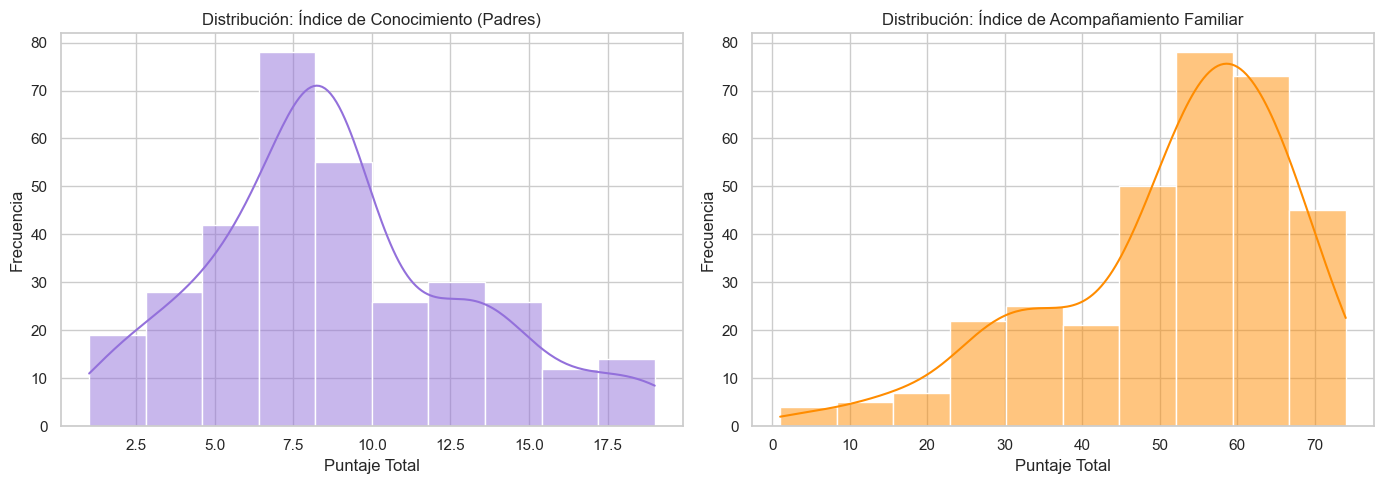

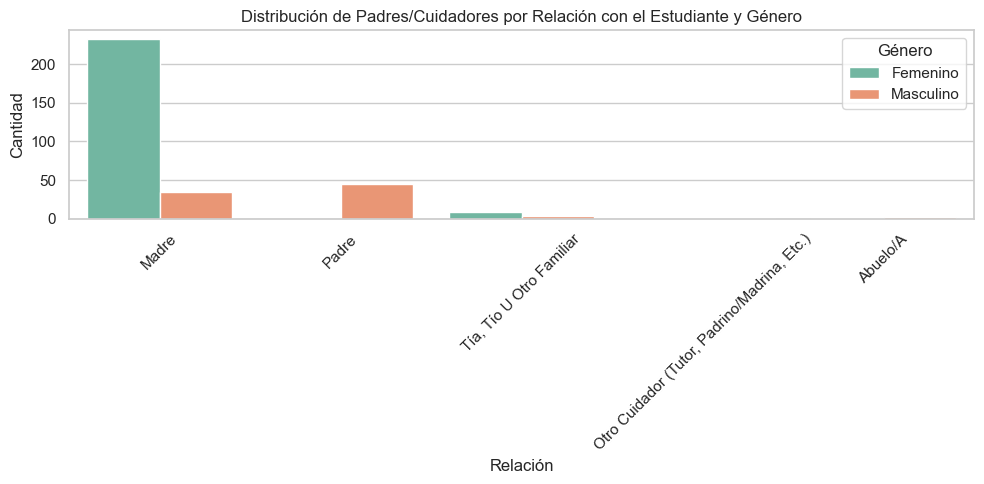

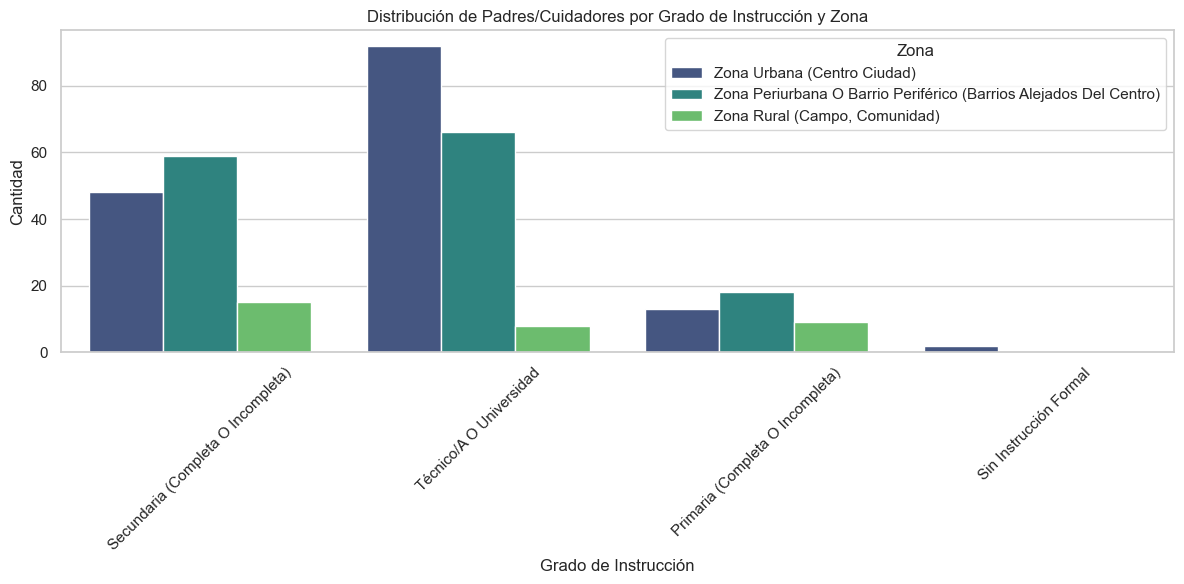

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma: Indice de Conocimiento
sns.histplot(df_padres['Indice_Conocimiento'], bins=10, kde=True, ax=axes[0], color='mediumpurple')
axes[0].set_title('Distribución: Índice de Conocimiento (Padres)')
axes[0].set_xlabel('Puntaje Total')
axes[0].set_ylabel('Frecuencia')

# Histograma: Indice de Acompañamiento
sns.histplot(df_padres['Indice_Acompanamiento'], bins=10, kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Distribución: Índice de Acompañamiento Familiar')
axes[1].set_xlabel('Puntaje Total')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# Gráfico: Distribución por Relación
plt.figure(figsize=(10, 5))
sns.countplot(data=df_padres, x='Dim_Relacion', hue='Dim_Genero', palette='Set2')
plt.title('Distribución de Padres/Cuidadores por Relación con el Estudiante y Género')
plt.xlabel('Relación')
plt.ylabel('Cantidad')
plt.legend(title='Género')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# Gráfico: Distribución por Grado de Instrucción y Zona
plt.figure(figsize=(12, 6))
sns.countplot(data=df_padres, x='Dim_Instruccion', hue='Dim_Zona', palette='viridis')
plt.title('Distribución de Padres/Cuidadores por Grado de Instrucción y Zona')
plt.xlabel('Grado de Instrucción')
plt.ylabel('Cantidad')
plt.legend(title='Zona')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 4. Exportación de Resultados

In [5]:
# Seleccionamos las columnas clave para el Dashboard
columnas_finales = [
    'ID_Control',
    'Dim_Municipio',
    'Dim_Unidad_Educativa',
    'Dim_Nivel_Hijo',
    'Dim_Relacion',
    'Dim_Edad',
    'Dim_Genero',
    'Dim_Instruccion',
    'Dim_Num_Hijos',
    'Dim_Zona',
    'Dim_Indigena',
    'Dim_Idioma',
    'Indice_Conocimiento',
    'Indice_Conocimiento_Norm',
    'Indice_Acompanamiento',
    'Indice_Acompanamiento_Norm'
]

cols_export = [c for c in columnas_finales if c in df_padres.columns]
df_final = df_padres[cols_export].copy()

output_path = '../output/df_padres_final.xlsx'
df_final.to_excel(output_path, index=False)
print(f"Archivo final de padres exportado exitosamente a: {output_path}")

Archivo final de padres exportado exitosamente a: ../output/df_padres_final.xlsx
